# **<span style="color: #c9a84c;">𓅄 Deliverable 4 - Progressive Transformer Fine-tuning</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

## <span style="color: #f0d080;">Contextual Sign Disambiguation: Moving from Sign Classification to Automated Sentence Translation</span>

<span style="color: #63ace0;">**CS437 / CS5317 / EE414 / EE513 - Deep Learning, Spring 2026**</span>

<span>**Authors:** 𓁐 Maryem Mahmood and Zehra Talat</span>

---

## **<span style="color: #c9a84c;">𓆣 Deliverable 4 Overview</span>**

<span style="color: #a8c4d8;">We improve on the Phase 3 transformer (73.51%) by loading its trained weights and applying **progressive fine-tuning** in two stages.</span>

**𓂋 Starting point:** Phase 3 CNN + Transformer - 73.51% per-position accuracy

**𓂋 Two-stage fine-tuning strategy:**

| Stage | What trains | Params | LR | Purpose |
|---|---|---|---|---|
| **Stage A** | Classifier FC layer only | ~45K | 1e-3 | Re-adapt output layer first |
| **Stage B** | Full transformer (all layers) | ~1.77M | 5e-4 | End-to-end fine-tuning |

**𓂋 Key difference from Phase 3:** Phase 3 trained from random init. Deliverable 4 loads Phase 3 weights and fine-tunes progressively - the model already knows hieroglyph context and we refine it further.


# **<span style="color: #c9a84c;">⚙ Section 0 - Environment Setup</span>**

In [1]:
import os, json, re, random, math, warnings, copy
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              accuracy_score)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


Device  : cuda
PyTorch : 2.10.0+cu128
GPU     : Tesla T4
VRAM    : 15.6 GB


# **<span style="color: #c9a84c;">𓇋 Section 1 - Load Phase 3 Assets</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">We load everything from Phase 3 outputs - the trained transformer weights, label maps, split CSVs, and frozen ResNet-18 backbone.</span>

**𓂋 Datasets needed on Kaggle (+ Add Input):**
- `phase3outputs` - upload the phase3outputs zip as a Kaggle dataset
- `phase1outputs` - already uploaded (contains resnet18_best.pth + split CSVs)
- `glyph2025` - already uploaded


In [2]:
# Paths - adjust to match your Kaggle dataset names
PHASE3_DIR = Path('/kaggle/input/datasets/maryemmahmood/phase-3-output/phase3outputs')
PHASE1_DIR = Path('/kaggle/input/datasets/maryemmahmood/phase-1-output/phase1outputs')
GLYPH_ROOT = Path('/kaggle/input/datasets/maryemmahmood/glyph2025/Glyph2025')

# Phase 3 files
TRANSFORMER_PTH = PHASE3_DIR / 'transformer_best.pth'
LABEL_MAP       = PHASE3_DIR / 'label_map.json'
IDX_LABEL       = PHASE3_DIR / 'idx_to_label.json'
PHASE3_RESULTS  = PHASE3_DIR / 'phase3_results.json'

# Phase 1 split CSVs (same split used throughout)
TRAIN_CSV = PHASE1_DIR / 'split_train.csv'
VAL_CSV   = PHASE1_DIR / 'split_val.csv'
TEST_CSV  = PHASE1_DIR / 'split_test.csv'

# ResNet-18 backbone
RESNET_PTH = PHASE1_DIR / 'resnet18_best.pth'

for p in [TRANSFORMER_PTH, LABEL_MAP, TRAIN_CSV, RESNET_PTH, GLYPH_ROOT]:
    assert p.exists(), f'Not found: {p}'

# Load label maps
with open(LABEL_MAP)  as f: label_to_idx = json.load(f)
with open(IDX_LABEL)  as f: idx_to_label = {int(k): v for k,v in json.load(f).items()}
NUM_CLASSES = len(label_to_idx)

# Load split CSVs
df_train = pd.read_csv(TRAIN_CSV)
df_val   = pd.read_csv(VAL_CSV)
df_test  = pd.read_csv(TEST_CSV)

# Load Phase 3 results as baseline
with open(PHASE3_RESULTS) as f: p3 = json.load(f)

print(f'NUM_CLASSES      : {NUM_CLASSES}')
print(f'Train images     : {len(df_train):,}')
print(f'Val images       : {len(df_val):,}')
print(f'Test images      : {len(df_test):,}')
print()
print('Phase 3 baseline to beat:')
print(f'  Per-Position Acc : {p3["per_position_acc"]*100:.2f}%')
print(f'  Macro F1         : {p3["macro_f1"]*100:.2f}%')
print(f'  Weighted F1      : {p3["weighted_f1"]*100:.2f}%')
print(f'  Best Val Acc     : {p3["best_val_acc"]*100:.2f}%')


NUM_CLASSES      : 176
Train images     : 8,985
Val images       : 1,925
Test images      : 1,926

Phase 3 baseline to beat:
  Per-Position Acc : 73.51%
  Macro F1         : 49.90%
  Weighted F1      : 71.07%
  Best Val Acc     : 73.13%


In [3]:
# Build label -> image paths from full Glyph2025
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}
label_to_paths = defaultdict(list)
for class_dir in sorted(GLYPH_ROOT.iterdir()):
    if class_dir.is_dir():
        lbl = class_dir.name.upper()
        if lbl in label_to_idx:
            for img in class_dir.glob('*'):
                if img.suffix.lower() in VALID_EXTS:
                    label_to_paths[lbl].append(str(img))

print(f'Classes with images : {len(label_to_paths)}')
print(f'Total images        : {sum(len(v) for v in label_to_paths.values()):,}')


Classes with images : 176
Total images        : 12,836


In [4]:
# ResNet-18 backbone - matches Phase 1 checkpoint exactly
class ResNetClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base = models.resnet18(weights=None)
        self.backbone = base
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(512, num_classes))
        self.feature_dim = 512

    def forward(self, x):
        return self.classifier(self.backbone(x))

    def extract_features(self, x):
        return self.backbone(x)  # (B, 512)

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False


resnet = ResNetClassifier(NUM_CLASSES).to(DEVICE)
resnet.load_state_dict(torch.load(RESNET_PTH, map_location=DEVICE))
resnet.freeze_backbone()
resnet.eval()
print(f'ResNet-18 loaded and frozen. Feature dim: {resnet.feature_dim}')


ResNet-18 loaded and frozen. Feature dim: 512


# **<span style="color: #c9a84c;">𓏏 Section 2 - Sequence Dataset</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">Same sequence construction as Phase 3 - Franken plate reading order + Glyph2025 images. This ensures fair comparison with Phase 3 results.</span>


In [5]:
def build_sequences(df, label_to_idx, min_len=3, max_len=50):
    sequences = []
    df_f = df.copy()
    if 'plate' not in df_f.columns:
        df_f['plate'] = df_f['path'].apply(
            lambda p: int(Path(p).name[:2])
            if re.match(r'^\d{6}_', Path(p).name) else -1)
        df_f['index'] = df_f['path'].apply(
            lambda p: int(Path(p).name[2:6])
            if re.match(r'^\d{6}_', Path(p).name) else -1)
    df_f = df_f[df_f['plate'] != -1]
    for plate, group in df_f.groupby('plate'):
        valid = group.sort_values('index')
        valid = valid[valid['label'].isin(label_to_idx)]
        if len(valid) < min_len:
            continue
        rows = valid.to_dict('records')
        for start in range(0, len(rows), max_len):
            chunk = rows[start:start + max_len]
            if len(chunk) >= min_len:
                sequences.append(chunk)
    return sequences


train_seqs = build_sequences(df_train, label_to_idx)
val_seqs   = build_sequences(df_val,   label_to_idx)
test_seqs  = build_sequences(df_test,  label_to_idx)

print(f'Train sequences : {len(train_seqs)}')
print(f'Val sequences   : {len(val_seqs)}')
print(f'Test sequences  : {len(test_seqs)}')
lengths = [len(s) for s in train_seqs + val_seqs + test_seqs]
print(f'Avg length      : {np.mean(lengths):.1f}')


Train sequences : 52
Val sequences   : 16
Test sequences  : 15
Avg length      : 41.7


In [6]:
IMG_SIZE = 224
MAX_SEQ_LEN = 50
PAD_IDX     = NUM_CLASSES

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def load_image(path):
    try: return Image.open(path).convert('RGB')
    except: return Image.new('RGB', (IMG_SIZE, IMG_SIZE), (128, 128, 128))


class GlyphSequenceDataset(Dataset):
    def __init__(self, sequences, label_to_idx, label_to_paths,
                 backbone, device, transform, max_len=MAX_SEQ_LEN):
        self.max_len = max_len
        self.samples = []
        backbone.eval()
        print(f'Pre-extracting features for {len(sequences)} sequences...')
        with torch.no_grad():
            for seq in sequences:
                imgs, labels = [], []
                for row in seq[:max_len]:
                    lbl   = row['label']
                    paths = label_to_paths.get(lbl, [row['path']])
                    img   = load_image(random.choice(paths))
                    imgs.append(transform(img))
                    labels.append(label_to_idx[lbl])
                if not imgs: continue
                feats = backbone.extract_features(torch.stack(imgs).to(device)).cpu()
                self.samples.append((feats, labels))
        print(f'  Done - {len(self.samples)} valid sequences')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        feats, labels = self.samples[idx]
        L       = len(labels)
        pad     = self.max_len - L
        feats_p = torch.cat([feats, torch.zeros(pad, feats.shape[1])], dim=0)
        label_t = torch.tensor(labels + [PAD_IDX]*pad, dtype=torch.long)
        mask    = torch.tensor([False]*L + [True]*pad)
        return feats_p, label_t, mask, L


print('Building datasets...')
train_ds = GlyphSequenceDataset(train_seqs, label_to_idx, label_to_paths, resnet, DEVICE, eval_tf)
val_ds   = GlyphSequenceDataset(val_seqs,   label_to_idx, label_to_paths, resnet, DEVICE, eval_tf)
test_ds  = GlyphSequenceDataset(test_seqs,  label_to_idx, label_to_paths, resnet, DEVICE, eval_tf)

SEQ_BATCH = 4
train_loader = DataLoader(train_ds, batch_size=SEQ_BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=SEQ_BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=SEQ_BATCH, shuffle=False, num_workers=0)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')


Building datasets...
Pre-extracting features for 52 sequences...
  Done - 52 valid sequences
Pre-extracting features for 16 sequences...
  Done - 16 valid sequences
Pre-extracting features for 15 sequences...
  Done - 15 valid sequences
Train batches : 13
Val batches   : 4
Test batches  : 4


# **<span style="color: #c9a84c;">𓊹 Section 3 - Transformer with Freeze/Unfreeze Controls</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">Same architecture as Phase 3 with added freeze/unfreeze methods for progressive training. We load the Phase 3 trained weights immediately after building the model.</span>

**𓂋 Stage A trains only the classifier (FC layer):**
```
input_proj  - FROZEN
pos_emb     - FROZEN
transformer - FROZEN
classifier  - TRAINABLE (Linear 256 -> 176, ~45K params)
```

**𓂋 Stage B unfreezes everything:**
```
input_proj  - TRAINABLE
pos_emb     - TRAINABLE
transformer - TRAINABLE
classifier  - TRAINABLE
Total: ~1.77M params
```


In [7]:
class HieroglyphTransformer(nn.Module):
    def __init__(self, num_classes, feat_dim=512, d_model=256,
                 num_heads=4, num_layers=3, d_ff=512,
                 dropout=0.1, max_len=MAX_SEQ_LEN):
        super().__init__()
        self.input_proj  = nn.Linear(feat_dim, d_model)
        self.pos_emb     = nn.Embedding(max_len, d_model)
        self.dropout     = nn.Dropout(dropout)
        encoder_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads,
            dim_feedforward=d_ff, dropout=dropout,
            activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier  = nn.Linear(d_model, num_classes)  # the FC layer
        nn.init.xavier_uniform_(self.input_proj.weight)
        nn.init.xavier_uniform_(self.classifier.weight)

    def forward(self, feats, src_key_padding_mask=None):
        B, N, _ = feats.shape
        x   = self.input_proj(feats)
        pos = torch.arange(N, device=feats.device).unsqueeze(0)
        x   = self.dropout(x + self.pos_emb(pos))
        x   = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
        return self.classifier(x)

    def freeze_all(self):
        for p in self.parameters():
            p.requires_grad = False

    def unfreeze_classifier_only(self):
        """Stage A: only the FC classifier layer is trainable"""
        self.freeze_all()
        for p in self.classifier.parameters():
            p.requires_grad = True

    def unfreeze_all(self):
        """Stage B: all transformer layers trainable"""
        for p in self.parameters():
            p.requires_grad = True


# Build transformer and load Phase 3 weights
transformer = HieroglyphTransformer(NUM_CLASSES).to(DEVICE)
transformer.load_state_dict(torch.load(TRANSFORMER_PTH, map_location=DEVICE))

total_p = sum(p.numel() for p in transformer.parameters())
cls_p   = sum(p.numel() for p in transformer.classifier.parameters())

print(f'Transformer loaded from Phase 3 checkpoint')
print(f'Phase 3 baseline : {p3["per_position_acc"]*100:.2f}% per-position accuracy')
print()
print(f'Total params     : {total_p:,}')
print(f'Classifier (FC)  : {cls_p:,} params')
print()
print(f'Stage A will train: {cls_p:,} params (FC classifier only)')
print(f'Stage B will train: {total_p:,} params (full transformer)')


Transformer loaded from Phase 3 checkpoint
Phase 3 baseline : 73.51% per-position accuracy

Total params     : 1,770,672
Classifier (FC)  : 45,232 params

Stage A will train: 45,232 params (FC classifier only)
Stage B will train: 1,770,672 params (full transformer)


# **<span style="color: #c9a84c;">𓅙 Section 4 - Training Utilities</span>**

In [8]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = correct = total = 0
    for feats, labels, mask, lengths in loader:
        feats  = feats.to(device)
        labels = labels.to(device)
        mask   = mask.to(device)
        optimizer.zero_grad()
        logits  = model(feats, src_key_padding_mask=mask)
        B, N, C = logits.shape
        valid   = ~mask.view(B*N)
        loss    = criterion(logits.view(B*N, C)[valid], labels.view(B*N)[valid])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * valid.sum().item()
        preds       = logits.view(B*N, C)[valid].argmax(1)
        correct    += (preds == labels.view(B*N)[valid]).sum().item()
        total      += valid.sum().item()
    return total_loss/total, correct/total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = correct = total = 0
    for feats, labels, mask, lengths in loader:
        feats  = feats.to(device)
        labels = labels.to(device)
        mask   = mask.to(device)
        logits  = model(feats, src_key_padding_mask=mask)
        B, N, C = logits.shape
        valid   = ~mask.view(B*N)
        loss    = criterion(logits.view(B*N, C)[valid], labels.view(B*N)[valid])
        total_loss += loss.item() * valid.sum().item()
        preds       = logits.view(B*N, C)[valid].argmax(1)
        correct    += (preds == labels.view(B*N)[valid]).sum().item()
        total      += valid.sum().item()
    return total_loss/total, correct/total


class WarmupCosine:
    def __init__(self, optimizer, warmup_eps, total_eps, base_lr):
        self.opt = optimizer; self.wu = warmup_eps
        self.total = total_eps; self.lr = base_lr; self.ep = 0
    def step(self):
        self.ep += 1
        ep = self.ep
        if ep <= self.wu:
            lr = self.lr * ep / self.wu
        else:
            progress = (ep - self.wu) / (self.total - self.wu)
            lr = self.lr * 0.5 * (1 + math.cos(math.pi * progress))
        for g in self.opt.param_groups:
            g['lr'] = lr
        return lr

print('Training utilities defined.')


Training utilities defined.


# **<span style="color: #c9a84c;">𓃒 Section 5 - Stage A: Classifier FC Layer Only</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">Freeze the entire transformer. Train **only the final fully connected classifier layer** (Linear 256 -> 176). This re-adapts the output mapping before full fine-tuning.</span>


In [9]:
print('=' * 65)
print('  STAGE A: CLASSIFIER FC LAYER ONLY')
print('  Entire transformer frozen except final Linear(256->176)')
print('=' * 65)

# Freeze everything, unfreeze only classifier FC
transformer.unfreeze_classifier_only()
trainable_a = sum(p.numel() for p in transformer.parameters() if p.requires_grad)
frozen_a    = sum(p.numel() for p in transformer.parameters() if not p.requires_grad)

print(f'  Trainable : {trainable_a:,} (classifier FC only)')
print(f'  Frozen    : {frozen_a:,} (all other layers)')
print()

EPOCHS_A  = 10
LR_A      = 1e-3
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)
optimizer_a = optim.Adam(
    filter(lambda p: p.requires_grad, transformer.parameters()), lr=LR_A
)

history_a  = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
best_val_a = 0.0
best_wts_a = copy.deepcopy(transformer.state_dict())

print(f'{"Ep":>4} {"TrLoss":>9} {"TrAcc%":>8} {"VaLoss":>9} {"VaAcc%":>8} {"Best%":>8}')
print('-' * 55)

for ep in range(1, EPOCHS_A + 1):
    tl, ta = train_epoch(transformer, train_loader, optimizer_a, criterion, DEVICE)
    vl, va = eval_epoch(transformer,  val_loader,   criterion,   DEVICE)
    history_a['train_loss'].append(tl); history_a['train_acc'].append(ta)
    history_a['val_loss'].append(vl);   history_a['val_acc'].append(va)
    mk = ''
    if va > best_val_a:
        best_val_a = va
        best_wts_a = copy.deepcopy(transformer.state_dict())
        mk = ' ★'
    print(f'{ep:>4} {tl:>9.4f} {ta*100:>8.2f} {vl:>9.4f} {va*100:>8.2f} {best_val_a*100:>8.2f}{mk}')

print(f'\nStage A complete.')
print(f'  Best val accuracy : {best_val_a*100:.2f}%')
print(f'  Phase 3 baseline  : {p3["best_val_acc"]*100:.2f}%')
print(f'  Delta             : {(best_val_a - p3["best_val_acc"])*100:+.2f}%')

# Load best Stage A weights before Stage B
transformer.load_state_dict(best_wts_a)


  STAGE A: CLASSIFIER FC LAYER ONLY
  Entire transformer frozen except final Linear(256->176)
  Trainable : 45,232 (classifier FC only)
  Frozen    : 1,725,440 (all other layers)

  Ep    TrLoss   TrAcc%    VaLoss   VaAcc%    Best%
-------------------------------------------------------
   1    0.9417    99.92    1.8870    72.76    72.76 ★
   2    0.9316    99.96    1.8873    73.51    73.51 ★
   3    0.9266   100.00    1.8873    73.13    73.51
   4    0.9207   100.00    1.8972    72.76    73.51
   5    0.9167   100.00    1.9051    72.57    73.51
   6    0.9143   100.00    1.8963    72.95    73.51
   7    0.9093   100.00    1.8984    72.57    73.51
   8    0.9076   100.00    1.9048    72.39    73.51
   9    0.9058   100.00    1.9045    72.39    73.51
  10    0.9039   100.00    1.9019    72.57    73.51

Stage A complete.
  Best val accuracy : 73.51%
  Phase 3 baseline  : 73.13%
  Delta             : +0.37%


<All keys matched successfully>

# **<span style="color: #c9a84c;">𓅙 Section 6 - Stage B: Full Transformer Fine-tuning</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">Unfreeze all transformer layers and fine-tune end-to-end at a lower learning rate with warmup.</span>


In [12]:
print('=' * 65)
print('  STAGE B: FULL TRANSFORMER FINE-TUNING')
print('  All layers unfrozen - projection, encoder, classifier')
print('=' * 65)

transformer.unfreeze_all()
trainable_b = sum(p.numel() for p in transformer.parameters() if p.requires_grad)
print(f'  Trainable : {trainable_b:,} (all layers)')
print()

EPOCHS_B  = 30
PATIENCE  = 15
LR_B      = 5e-5
WARMUP_B  = 2

optimizer_b = optim.AdamW(transformer.parameters(), lr=LR_B, weight_decay=0.05)
scheduler_b = WarmupCosine(optimizer_b, WARMUP_B, EPOCHS_B, LR_B)

history_b    = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'lr':[]}
best_val_b   = best_val_a  # continue from Stage A best
best_wts     = copy.deepcopy(transformer.state_dict())
patience_ctr = 0

print(f'{"Ep":>4} {"TrLoss":>9} {"TrAcc%":>8} {"VaLoss":>9} {"VaAcc%":>8} {"Best%":>8} {"LR":>10}')
print('-' * 65)

for ep in range(1, EPOCHS_B + 1):
    lr = scheduler_b.step()
    tl, ta = train_epoch(transformer, train_loader, optimizer_b, criterion, DEVICE)
    vl, va = eval_epoch(transformer,  val_loader,   criterion,   DEVICE)

    history_b['train_loss'].append(tl); history_b['train_acc'].append(ta)
    history_b['val_loss'].append(vl);   history_b['val_acc'].append(va)
    history_b['lr'].append(lr)

    mk = ''
    if va > best_val_b:
        best_val_b   = va
        best_wts     = copy.deepcopy(transformer.state_dict())
        patience_ctr = 0
        mk = ' ★'
    else:
        patience_ctr += 1

    print(f'{ep:>4} {tl:>9.4f} {ta*100:>8.2f} {vl:>9.4f} {va*100:>8.2f} '
          f'{best_val_b*100:>8.2f} {lr:>10.2e}{mk}')

    if patience_ctr >= PATIENCE:
        print(f'\nEarly stopping at epoch {ep}')
        break

print(f'\nStage B complete.')
print(f'  Best val accuracy : {best_val_b*100:.2f}%')
print(f'  Stage A best      : {best_val_a*100:.2f}%')
print(f'  Phase 3 baseline  : {p3["best_val_acc"]*100:.2f}%')


  STAGE B: FULL TRANSFORMER FINE-TUNING
  All layers unfrozen - projection, encoder, classifier
  Trainable : 1,770,672 (all layers)

  Ep    TrLoss   TrAcc%    VaLoss   VaAcc%    Best%         LR
-----------------------------------------------------------------
   1    0.8843    99.96    1.8704    73.32    73.51   2.50e-05
   2    0.8836    99.96    1.8665    73.51    73.51   5.00e-05
   3    0.8818   100.00    1.8759    72.95    73.51   4.98e-05
   4    0.8825    99.92    1.8676    73.13    73.51   4.94e-05
   5    0.8817   100.00    1.8593    74.07    74.07   4.86e-05 ★
   6    0.8794   100.00    1.8666    73.32    74.07   4.75e-05
   7    0.8816    99.96    1.8588    73.88    74.07   4.62e-05
   8    0.8797   100.00    1.8673    74.07    74.07   4.45e-05
   9    0.8797    99.92    1.8742    73.32    74.07   4.27e-05
  10    0.8795   100.00    1.8687    73.32    74.07   4.06e-05
  11    0.8789   100.00    1.8711    73.13    74.07   3.83e-05
  12    0.8793    99.92    1.8711    73.32

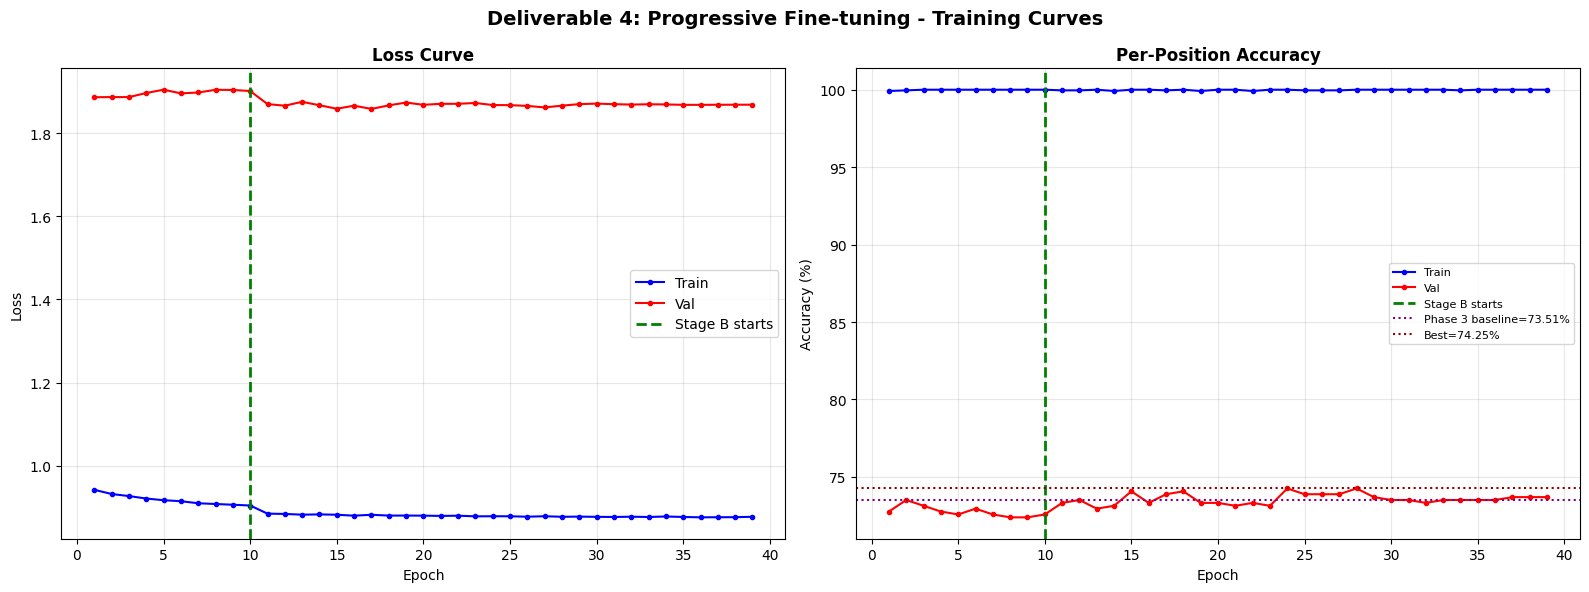

In [13]:
# Combined learning curves for both stages
all_tl = history_a['train_loss'] + history_b['train_loss']
all_vl = history_a['val_loss']   + history_b['val_loss']
all_ta = history_a['train_acc']  + history_b['train_acc']
all_va = history_a['val_acc']    + history_b['val_acc']
eps    = range(1, len(all_tl) + 1)
split  = len(history_a['train_loss'])  # epoch where Stage B starts

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(eps, all_tl, 'b-o', ms=3, label='Train')
axes[0].plot(eps, all_vl, 'r-o', ms=3, label='Val')
axes[0].axvline(split, color='green', linestyle='--', lw=2, label='Stage B starts')
axes[0].set_title('Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(eps, [a*100 for a in all_ta], 'b-o', ms=3, label='Train')
axes[1].plot(eps, [a*100 for a in all_va], 'r-o', ms=3, label='Val')
axes[1].axvline(split, color='green', linestyle='--', lw=2, label='Stage B starts')
axes[1].axhline(p3['per_position_acc']*100, color='purple', linestyle=':',
                lw=1.5, label=f'Phase 3 baseline={p3["per_position_acc"]*100:.2f}%')
axes[1].axhline(best_val_b*100, color='darkred', linestyle=':',
                lw=1.5, label=f'Best={best_val_b*100:.2f}%')
axes[1].set_title('Per-Position Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.suptitle('Deliverable 4: Progressive Fine-tuning - Training Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('d4_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


# **<span style="color: #c9a84c;">📈 Section 7 - Final Test Evaluation</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">


In [16]:
# Load best weights and evaluate on held-out test set
transformer.load_state_dict(best_wts)
transformer.eval()

all_preds  = []
all_labels = []
seq_correct = 0
seq_total   = 0

with torch.no_grad():
    for feats, labels, mask, lengths in test_loader:
        feats  = feats.to(DEVICE)
        labels = labels.to(DEVICE)
        mask   = mask.to(DEVICE)
        logits = transformer(feats, src_key_padding_mask=mask)
        preds  = logits.argmax(-1)
        B = feats.size(0)
        for i in range(B):
            L        = lengths[i].item()
            pred_seq = preds[i, :L].cpu().tolist()
            true_seq = labels[i, :L].cpu().tolist()
            all_preds.extend(pred_seq)
            all_labels.extend(true_seq)
            seq_total += 1
            if pred_seq == true_seq:
                seq_correct += 1

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

pos_acc     = accuracy_score(all_labels, all_preds)
seq_acc     = seq_correct / max(seq_total, 1)
macro_f1    = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
macro_prec  = precision_score(all_labels, all_preds, average='macro', zero_division=0)
macro_rec   = recall_score(all_labels, all_preds,    average='macro', zero_division=0)

print('=' * 65)
print('  DELIVERABLE 4 - FINAL TEST RESULTS')
print('  Progressive fine-tuning from Phase 3 weights')
print('=' * 65)
print(f'  Per-Position Accuracy : {pos_acc*100:.2f}%')
print(f'  Macro Precision       : {macro_prec*100:.2f}%')
print(f'  Macro Recall          : {macro_rec*100:.2f}%')
print(f'  Macro F1-Score        : {macro_f1*100:.2f}%')
print(f'  Weighted F1-Score     : {weighted_f1*100:.2f}%')
print('=' * 65)
print()
print('Comparison:')
print(f'  Phase 1  ResNet-18 (isolated)     : {p3["phase1_top1"]*100:.2f}%')
print(f'  Phase 3  CNN + Transformer        : {p3["per_position_acc"]*100:.2f}%')
print(f'  Deliv 4  Progressive fine-tuning  : {pos_acc*100:.2f}%')
print(f'  Delta vs Phase 3                  : {(pos_acc - p3["per_position_acc"])*100:+.2f}%')

torch.save(best_wts, 'transformer_finetuned_best.pth')
print('\nCheckpoint saved: transformer_finetuned_best.pth')


  DELIVERABLE 4 - FINAL TEST RESULTS
  Progressive fine-tuning from Phase 3 weights
  Per-Position Accuracy : 73.71%
  Macro Precision       : 51.10%
  Macro Recall          : 48.36%
  Macro F1-Score        : 48.41%
  Weighted F1-Score     : 70.73%

Comparison:
  Phase 1  ResNet-18 (isolated)     : 66.72%
  Phase 3  CNN + Transformer        : 73.51%
  Deliv 4  Progressive fine-tuning  : 73.71%
  Delta vs Phase 3                  : +0.20%

Checkpoint saved: transformer_finetuned_best.pth


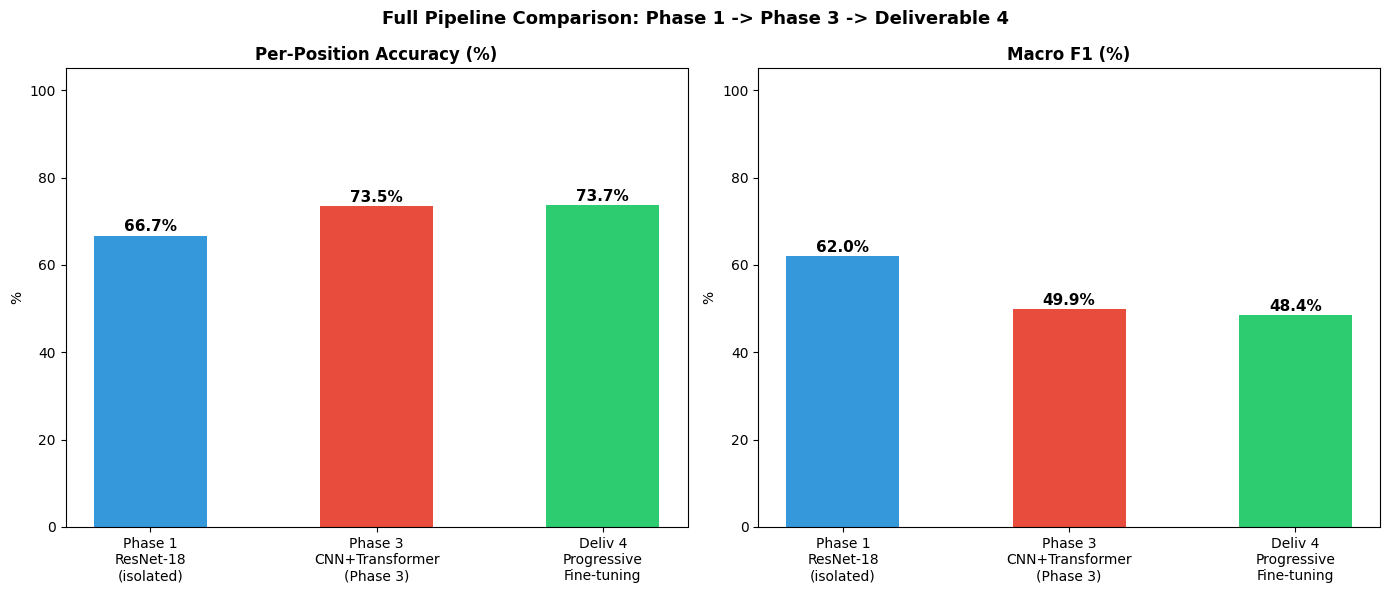

In [18]:
# Cross-phase comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

phases  = ['Phase 1\nResNet-18\n(isolated)', 'Phase 3\nCNN+Transformer\n(Phase 3)', 'Deliv 4\nProgressive\nFine-tuning']
acc_vals= [p3['phase1_top1']*100, p3['per_position_acc']*100, pos_acc*100]
f1_vals = [62.05, p3['macro_f1']*100, macro_f1*100]
colors  = ['#3498db', '#e74c3c', '#2ecc71']

for ax, vals, title in [(axes[0], acc_vals, 'Per-Position Accuracy (%)'),
                         (axes[1], f1_vals,  'Macro F1 (%)')]:
    bars = ax.bar(phases, vals, color=colors, width=0.5)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('%'); ax.set_ylim(0, 105)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Full Pipeline Comparison: Phase 1 -> Phase 3 -> Deliverable 4',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('d4_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# **<span style="color: #c9a84c;">💾 Section 8 - Save Artifacts</span>**

In [19]:
from pathlib import Path
import json

SAVE_DIR = Path('/kaggle/working')

torch.save(best_wts, SAVE_DIR / 'transformer_finetuned_best.pth')

d4_results = {
    'model'            : 'CNN + Transformer (progressive fine-tuning from Phase 3)',
    'dataset'          : 'Glyph2025 sequences (Franken reading order)',
    'num_classes'      : NUM_CLASSES,
    'stage_a_best_val' : float(best_val_a),
    'stage_b_best_val' : float(best_val_b),
    'per_position_acc' : float(pos_acc),
    'sequence_acc'     : float(seq_acc),
    'macro_f1'         : float(macro_f1),
    'weighted_f1'      : float(weighted_f1),
    'macro_precision'  : float(macro_prec),
    'macro_recall'     : float(macro_rec),
    'phase3_baseline'  : p3['per_position_acc'],
    'delta_vs_phase3'  : float(pos_acc) - p3['per_position_acc'],
    'phase1_baseline'  : p3['phase1_top1'],
    'delta_vs_phase1'  : float(pos_acc) - p3['phase1_top1'],
}

with open(SAVE_DIR / 'd4_results.json', 'w') as f:
    json.dump(d4_results, f, indent=2)

print('Files saved:')
for f in sorted(SAVE_DIR.glob('*')):
    if f.is_file():
        print(f'  {f.name}  ({f.stat().st_size/1024:.0f} KB)')

print()
print('=' * 65)
print('  DELIVERABLE 4 COMPLETE')
print('=' * 65)
print(f'  Phase 1 baseline : {p3["phase1_top1"]*100:.2f}%')
print(f'  Phase 3 baseline : {p3["per_position_acc"]*100:.2f}%')
print(f'  Deliverable 4    : {pos_acc*100:.2f}%')
print(f'  Delta vs Phase 3 : {(pos_acc - p3["per_position_acc"])*100:+.2f}%')
print('=' * 65)


Files saved:
  d4_comparison.png  (68 KB)
  d4_results.json  (1 KB)
  d4_training_curves.png  (98 KB)
  transformer_finetuned_best.pth  (6933 KB)

  DELIVERABLE 4 COMPLETE
  Phase 1 baseline : 66.72%
  Phase 3 baseline : 73.51%
  Deliverable 4    : 73.71%
  Delta vs Phase 3 : +0.20%
